## Context & Methods

### Hypothetical portfolio business problem

**Scenario.** A hypothetical sustainable-chemicals company must decide which heterogeneous CO₂-hydrogenation catalyst formulations to test next for a lower-carbon methanol product. Laboratory capacity is limited, catalyst inputs vary in cost and critical-material exposure, and a formulation that improves conversion can still fail if it increases methane, uncertainty, process cost, or lifecycle emissions.

**Executive decision.** The R&D and New Product Development leadership team needs a defensible shortlist for the next experimental generation and an evidence trail connecting laboratory performance to technical, sustainability, and financial stage gates.

**Stakeholders.** Catalyst R&D, process engineering, sustainability/LCA, procurement, product development, and finance.

**Portfolio value proposition.** This data product shows how to govern a sequential scientific dataset, detect campaign confounding, compare nonlinear models prospectively, translate catalyst results into decision KPIs, and state clearly where experimental evidence ends and business scenarios begin.

**Climate context.** The supplied *IPCC Climate Change 2022: Mitigation of Climate Change - Summary for Policymakers* is used only to frame the broader mitigation challenge. It does not supply catalyst-performance labels, TEA inputs, or notebook results.

### Key assumptions

- One row is one laboratory experiment; a stable experiment ID is required in production.
- Generation is the chronological decision batch. Training for generation *g* uses only generations `< g`.
- Continuous targets are primary. Stage-gate labels are derived from training-only thresholds or frozen commercial specifications.
- TEA/LCA outputs below are screening scenarios, not validated plant economics or product LCAs.


In [ ]:
from pathlib import Path
import hashlib, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA, NMF
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from scipy.spatial.distance import cdist
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,'axes.titlesize':13,'axes.labelsize':11})
RANDOM_SEED = 42
SOURCE_COMMIT = '8d8aeca37f2be53e4efeacbb79cfa49bc1d863bc'
DATA_CANDIDATES = [Path('outputs/data/MergedDataFinal.xlsx'), Path('data/MergedDataFinal.xlsx'), Path('MergedDataFinal.xlsx')]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), DATA_CANDIDATES[0])
SHEET_NAME = 'AllGen275DataProcessed'
TOP_K = 5
TARGET_PRODUCTIVITY = None  # Set a frozen commercial threshold when available.

## Data

### 1. Load one versioned dataset and lock the cohort

Production policy: store the immutable raw file, its SHA-256 checksum, schema, inclusion rules, and a row-level exclusion reason. `2_NoCost` is retained for chemistry modeling and excluded only from cost comparisons. The fallback generator exists solely to make this notebook executable for review.


In [ ]:
METALS = ['Cu','Zn','Ce','K','In','Fe','Co']
METAL_COLS = [f'{m} Loading [wt%]' for m in METALS]

def synthetic_demo(seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    rows=[]
    supports=['Al2O3','SiO2','TiO2','ZrO2']
    for g in range(1,6):
        for i in range(24):
            support = rng.choice(supports) if g == 1 else 'ZrO2'
            alpha=np.array([2.2+0.55*g,.8,.35,.2,.25,.25,.3])
            total=rng.uniform(2.5,7.0); comp=rng.dirichlet(alpha)*total
            cu,zn,ce,k,ind,fe,co=comp
            conv=np.clip(1.2+1.5*cu+.5*zn-1.4*k-.7*co+(support=='ZrO2')*1.5+rng.normal(0,.8),.1,20)
            meoh=np.clip(8+8*cu+2*zn-9*k-7*co+(support=='ZrO2')*8+rng.normal(0,5),0,85)
            ch4=np.clip(2+15*co+5*fe-2*cu+rng.normal(0,2),0,80)
            rate=conv/100*meoh/100*rng.uniform(.8,1.3)
            cost=18+38*co+55*ind+12*cu+8*zn+rng.normal(0,2)
            rows.append([f'G{g}-{i+1:02d}',str(g),support,total,*comp,cost,conv,meoh,ch4,rate])
    for i in range(23):
        total=rng.uniform(3,6); comp=rng.dirichlet([.2,.2,.2,.2,4,.2,.2])*total
        rows.append([f'G2N-{i+1:02d}','2_NoCost','ZrO2',total,*comp,np.nan,4,25,5,.01])
    cols=['Experiment ID','Generation','Support','Total Metal Loading [wt%]',*METAL_COLS,'Cost [$/kg]',
          'CO2 Conversion (%)','MeOH Selectivity (%)','CH4 Selectivity(%)','MeOH Formation Rate [mol/(h*gMetal)]']
    return pd.DataFrame(rows,columns=cols)

if DATA_PATH.exists():
    raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
    DATA_MODE='OBSERVED'
    source_hash=hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
else:
    raw=synthetic_demo(); DATA_MODE='SYNTHETIC DEMONSTRATION'; source_hash='synthetic-seed-42'

raw.columns=raw.columns.str.strip()
if 'Experiment ID' not in raw: raw['Experiment ID']=raw.index.map(lambda x:f'row-{x:04d}')
raw['Generation']=raw['Generation'].astype(str)
raw['is_no_cost_cohort']=raw['Generation'].str.contains('NoCost',case=False,na=False)
raw['generation_num']=pd.to_numeric(raw['Generation'].str.extract(r'(\d+)')[0],errors='coerce')

required=['Experiment ID','Generation','Support','Total Metal Loading [wt%]',*METAL_COLS,'CO2 Conversion (%)',
          'MeOH Selectivity (%)','CH4 Selectivity(%)','MeOH Formation Rate [mol/(h*gMetal)]','Cost [$/kg]']
missing=[c for c in required if c not in raw]
assert not missing, f'Missing required columns: {missing}'
assert raw['Experiment ID'].is_unique, 'Experiment ID must be unique.'
assert raw[METAL_COLS].min().min() >= 0, 'Metal loadings must be non-negative.'
assert ((raw['CO2 Conversion (%)'].between(0,100)) & (raw['MeOH Selectivity (%)'].between(0,100)) & (raw['CH4 Selectivity(%)'].between(0,100))).all()

display(raw.groupby(['Generation','Support'],dropna=False).size().rename('n').reset_index())


,Generation,Support,n
0,1,Al2O3,8
1,1,SiO2,3
2,1,TiO2,8
3,1,ZrO2,5
4,2,ZrO2,24
5,2_NoCost,ZrO2,23
6,3,ZrO2,24
7,4,ZrO2,24
8,5,ZrO2,24


## Results

### 2. Confounding and Simpson's-paradox diagnostics (run before modeling)

We compare marginal and support-adjusted slopes, but call a reversal a **candidate** only when both slopes are estimable and their signs differ. Because support collapses to ZrO₂ after the first generation, the diagnostic is paired with a support-allocation graph and cannot identify a causal support effect. The recommended experiment is a randomized support crossover within the same generation and formulation neighborhood, with laboratory replicates.


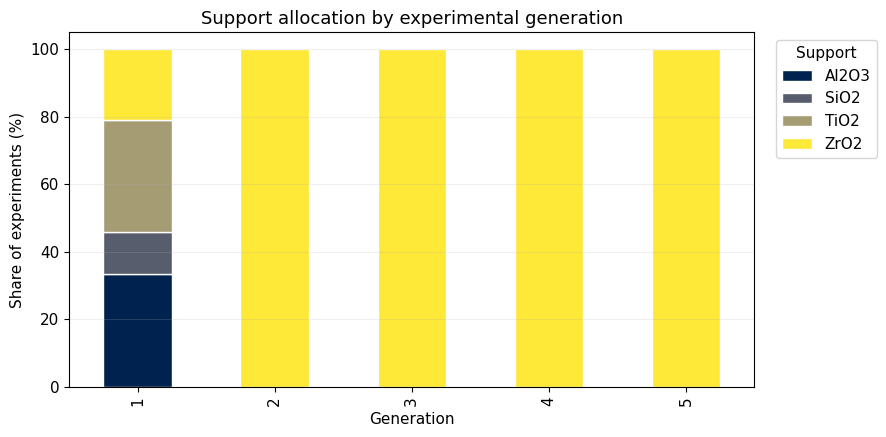

,target,feature,marginal_slope,adjusted_slope,sign_reversal_candidate,adjusted_p_value
2,CO2 Conversion (%),Ce Loading [wt%],-0.0413,0.0871,True,0.7048
11,MeOH Selectivity (%),In Loading [wt%],-0.1355,1.7103,True,0.2046
14,CH4 Selectivity(%),Cu Loading [wt%],-0.9089,-0.9762,False,0.0000
15,CH4 Selectivity(%),Zn Loading [wt%],0.3246,0.3623,False,0.1431
16,CH4 Selectivity(%),Ce Loading [wt%],-0.4454,-0.7560,False,0.1524
17,CH4 Selectivity(%),K Loading [wt%],-0.3787,-0.1932,False,0.7631
18,CH4 Selectivity(%),In Loading [wt%],-0.3141,-0.1081,False,0.8287
19,CH4 Selectivity(%),Fe Loading [wt%],3.2335,3.3722,False,0.0000
20,CH4 Selectivity(%),Co Loading [wt%],11.3937,11.1453,False,0.0000
0,CO2 Conversion (%),Cu Loading [wt%],1.5521,1.4637,False,0.0000


Interpretation: sign reversals flag policy-confounded associations; they are not causal estimates.


In [ ]:
analysis = raw.loc[~raw['is_no_cost_cohort']].copy()
overlap = pd.crosstab(analysis['generation_num'],analysis['Support'])
overlap_pct=overlap.div(overlap.sum(axis=1),axis=0)*100
ax=overlap_pct.plot(kind='bar',stacked=True,figsize=(9,4.5),colormap='cividis',edgecolor='white')
ax.set(title='Support allocation by experimental generation',xlabel='Generation',ylabel='Share of experiments (%)')
ax.legend(title='Support',bbox_to_anchor=(1.02,1)); ax.grid(axis='y',alpha=.2); plt.tight_layout(); plt.show()

safe = {c:c.replace(' ','_').replace('[','').replace(']','').replace('%','pct').replace('(','').replace(')','').replace('/','_') for c in METAL_COLS}
diag=analysis.rename(columns=safe).copy()
results=[]
for target in ['CO2 Conversion (%)','MeOH Selectivity (%)','CH4 Selectivity(%)']:
    y='y'; temp=diag.rename(columns={target:y})
    xs=list(safe.values())
    marginal=smf.ols('y ~ '+' + '.join(xs),data=temp).fit()
    adjusted=smf.ols('y ~ '+' + '.join(xs)+' + C(Support) + C(generation_num)',data=temp).fit()
    for original,x in zip(METAL_COLS,xs):
        a,b=marginal.params[x],adjusted.params[x]
        results.append([target,original,a,b,np.sign(a)!=np.sign(b),adjusted.pvalues[x]])
confounding=pd.DataFrame(results,columns=['target','feature','marginal_slope','adjusted_slope','sign_reversal_candidate','adjusted_p_value'])
display(confounding.sort_values(['sign_reversal_candidate','target'],ascending=[False,True]).round(4))
print('Interpretation: sign reversals flag policy-confounded associations; they are not causal estimates.')


### 3. Continuous decision KPIs

Definitions:

- Methanol yield proxy = CO₂ conversion fraction × MeOH selectivity fraction.
- Catalyst-mass productivity = metal-normalized MeOH rate × total metal loading fraction.
- Cost-efficiency proxy = catalyst-mass productivity ÷ catalyst cost. It is **not** production cost.


In [ ]:
df=raw.copy()
df['MeOH yield proxy']=df['CO2 Conversion (%)']/100*df['MeOH Selectivity (%)']/100
df['Catalyst-mass MeOH productivity']=df['MeOH Formation Rate [mol/(h*gMetal)]']*df['Total Metal Loading [wt%]']/100
df['Cost-efficiency proxy']=np.where((~df['is_no_cost_cohort']) & df['Cost [$/kg]'].gt(0),
                                     df['Catalyst-mass MeOH productivity']/df['Cost [$/kg]'],np.nan)
assert df.loc[df['is_no_cost_cohort'],'Cost-efficiency proxy'].isna().all()
kpi_summary=df.loc[~df['is_no_cost_cohort']].groupby('Generation').agg(n=('Experiment ID','size'),
    yield_proxy_median=('MeOH yield proxy','median'),productivity_best=('Catalyst-mass MeOH productivity','max'),
    cost_efficiency_best=('Cost-efficiency proxy','max')).reset_index()
display(kpi_summary.round(6))


,Generation,n,yield_proxy_median,productivity_best,cost_efficiency_best
0,1,24,0.012246,0.003704,0.000037
1,2,24,0.026463,0.005148,0.000056
2,3,24,0.028043,0.004289,0.000048
3,4,24,0.027385,0.005373,0.000064
4,5,24,0.032710,0.004223,0.000047


### 3a. Descriptive statistics and campaign-evolution graphs

These views separate distribution, generation, and relationship questions. They are diagnostic—not evidence that later generations improved because of ML, since campaign policy and chemistry changed together.


,count,mean,std,min,10%,25%,50%,75%,90%,max
CO2 Conversion (%),120.0,6.9363,2.1448,1.6998,4.2740,5.3584,6.8788,8.3773,9.6536,12.1035
MeOH Selectivity (%),120.0,36.9871,12.4330,5.6631,22.4480,28.7535,37.2678,45.9676,53.6722,65.7844
CH4 Selectivity(%),120.0,2.8348,4.8965,0.0000,0.0000,0.0000,0.4248,3.6079,8.5857,23.7360
Catalyst-mass MeOH productivity,120.0,0.0015,0.0012,0.0000,0.0004,0.0006,0.0011,0.0021,0.0034,0.0054


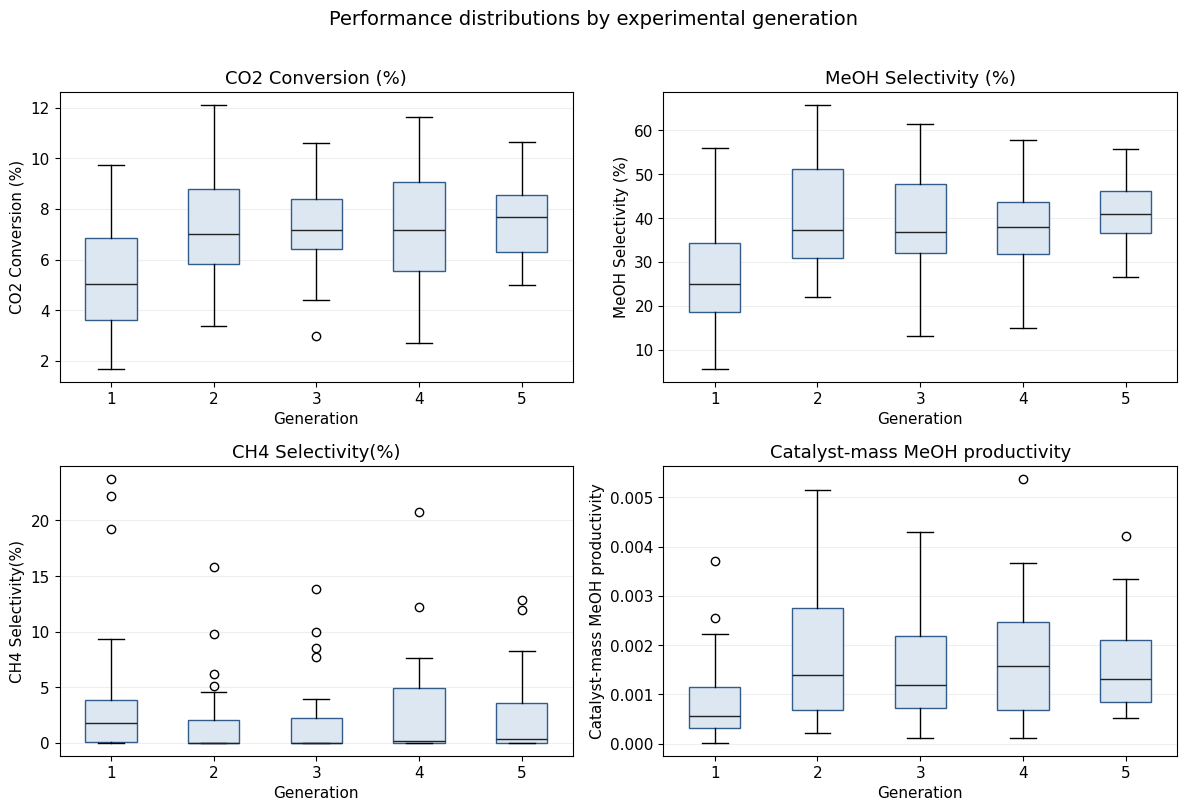

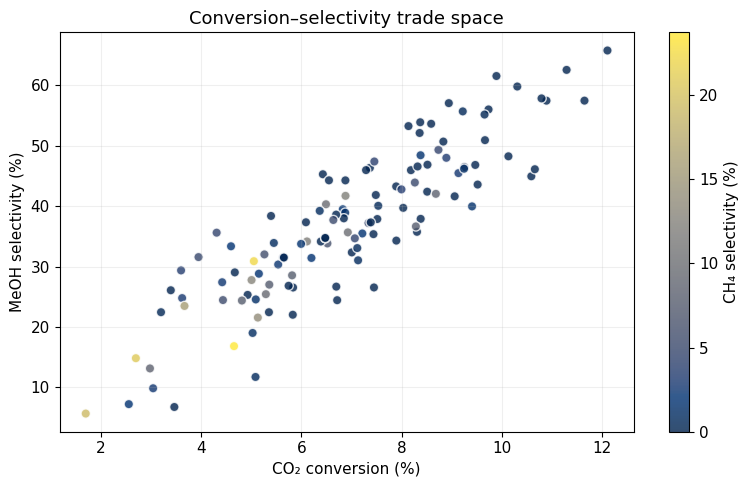

In [ ]:
performance_columns=['CO2 Conversion (%)','MeOH Selectivity (%)','CH4 Selectivity(%)','Catalyst-mass MeOH productivity']
display(df.loc[~df['is_no_cost_cohort'],performance_columns].describe(percentiles=[.1,.25,.5,.75,.9]).T.round(4))
plot_df=df.loc[~df['is_no_cost_cohort']].copy()

palette='#315C8C'; accent='#D07A32'
fig,axes=plt.subplots(2,2,figsize=(12,8))
for ax,col in zip(axes.flat,performance_columns):
    groups=[plot_df.loc[plot_df.generation_num==g,col].dropna().values for g in sorted(plot_df.generation_num.unique())]
    bp=ax.boxplot(groups,patch_artist=True,medianprops={'color':'#222222'},showfliers=True)
    for box in bp['boxes']: box.set(facecolor='#DCE7F2',edgecolor=palette)
    ax.set(title=col,xlabel='Generation',ylabel=col); ax.grid(axis='y',alpha=.2)
fig.suptitle('Performance distributions by experimental generation',y=1.01,fontsize=14)
fig.tight_layout(); plt.show()

plt.figure(figsize=(8,5));
scatter=plt.scatter(plot_df['CO2 Conversion (%)'],plot_df['MeOH Selectivity (%)'],c=plot_df['CH4 Selectivity(%)'],cmap='cividis',s=45,alpha=.8,edgecolor='white')
plt.colorbar(scatter,label='CH₄ selectivity (%)'); plt.xlabel('CO₂ conversion (%)'); plt.ylabel('MeOH selectivity (%)'); plt.title('Conversion–selectivity trade space'); plt.grid(alpha=.2); plt.tight_layout(); plt.show()


### 4. Chemically appropriate feature representation

The model uses total loading plus centered log-ratios of within-metal shares (with a small pseudocount), avoiding the exact sum constraint. Support is one-hot encoded. In production, compare this with a domain-approved mixture-process model and interactions chosen before seeing test performance.


In [ ]:
def add_composition_features(frame, eps=1e-6):
    out=frame.copy(); metal=out[METAL_COLS].astype(float).clip(lower=0)+eps
    shares=metal.div(metal.sum(axis=1),axis=0)
    clr=np.log(shares).sub(np.log(shares).mean(axis=1),axis=0)
    for m,c in zip(METALS,clr.columns): out[f'clr_{m}']=clr[c]
    return out

model_df=add_composition_features(df.loc[~df['is_no_cost_cohort']].copy())
clr_cols=[f'clr_{m}' for m in METALS[:-1]]  # one CLR coordinate is redundant
numeric_features=['Total Metal Loading [wt%]',*clr_cols]
categorical_features=['Support']
pre=ColumnTransformer([('num',Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler())]),numeric_features),
                       ('cat',OneHotEncoder(handle_unknown='ignore',sparse_output=False),categorical_features)])


### 5. Nonlinear stage-gate models: separate prospective analyses

The models are **Random Forest, Bagging, Decision Tree, SVM, Gradient Boosting, Voting Classifier, and ANN**. Each is evaluated separately using rolling-generation prediction for three explicit stage-gate targets: CO₂ conversion, MeOH selectivity, and CH₄ selectivity. For every fold, `bad / good / best` thresholds are calculated from the training generations only; lower CH₄ is treated as better. This prevents the held-out generation from defining its own label.


In [ ]:
CLASS_ORDER=['bad','good','best']
TARGET_SPECS={'CO2 Class':('CO2 Conversion (%)',False),'MeOH Class':('MeOH Selectivity (%)',False),'CH4 Class':('CH4 Selectivity(%)',True)}

def stage_labels(values, low, high, reverse=False):
    values=np.asarray(values,float)
    labels=np.where(values<low,'bad',np.where(values<high,'good','best'))
    if reverse: labels=np.where(values<low,'best',np.where(values<high,'good','bad'))
    return labels

def requested_models():
    rf=RandomForestClassifier(n_estimators=250,max_depth=6,min_samples_leaf=2,class_weight='balanced',random_state=RANDOM_SEED)
    gb=GradientBoostingClassifier(n_estimators=120,max_depth=2,learning_rate=.04,random_state=RANDOM_SEED)
    svm=SVC(C=2.0,kernel='rbf',class_weight='balanced',probability=True,random_state=RANDOM_SEED)
    return {
      'Random Forest':rf,
      'Bagging':BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5,class_weight='balanced',random_state=RANDOM_SEED),n_estimators=150,random_state=RANDOM_SEED),
      'Decision Tree':DecisionTreeClassifier(max_depth=5,min_samples_leaf=3,class_weight='balanced',random_state=RANDOM_SEED),
      'SVM':svm,
      'Gradient Boosting':gb,
      'Voting Classifier':VotingClassifier(estimators=[('rf',rf),('gb',gb),('svm',svm)],voting='soft'),
      'ANN':MLPClassifier(hidden_layer_sizes=(24,12),alpha=.01,max_iter=1500,early_stopping=True,random_state=RANDOM_SEED)}

scores=[]; classification_predictions=[]
for generation in sorted(model_df.generation_num.unique()):
    if generation<=1: continue
    train=model_df[model_df.generation_num<generation].copy(); test=model_df[model_df.generation_num==generation].copy()
    X_train=pre.fit_transform(train); X_test=pre.transform(test)
    for target_name,(target_column,reverse) in TARGET_SPECS.items():
        low,high=train[target_column].quantile([.33,.66])
        y_train=stage_labels(train[target_column],low,high,reverse)
        y_test=stage_labels(test[target_column],low,high,reverse)

        # Initialize OrdinalEncoder outside the inner loop to ensure consistent mapping across models
        # for numerical conversion. Use it only for ANN for the specific issue.
        le = OrdinalEncoder(categories=[CLASS_ORDER])

        for model_name,model in requested_models().items():
            if model_name == 'ANN':
                # For ANN, encode string labels to numerical ones for fitting
                y_train_encoded = le.fit_transform(y_train.reshape(-1, 1)).ravel()
                y_test_encoded = le.transform(y_test.reshape(-1, 1)).ravel()
                model.fit(X_train, y_train_encoded)
                predicted_encoded = model.predict(X_test)
                # Inverse transform predictions back to string labels for consistency
                predicted = le.inverse_transform(predicted_encoded.reshape(-1, 1)).ravel()
            else:
                model.fit(X_train,y_train)
                predicted=model.predict(X_test)
            score=balanced_accuracy_score(y_test,predicted)
            scores.append([int(generation),target_name,model_name,score])
            classification_predictions.extend([[int(generation),target_name,model_name,a,p] for a,p in zip(y_test,predicted)])

classification_scores=pd.DataFrame(scores,columns=['generation','target','model','balanced_accuracy'])
classification_predictions=pd.DataFrame(classification_predictions,columns=['generation','target','model','actual','predicted'])
model_target_summary=classification_scores.groupby(['model','target'],as_index=False).balanced_accuracy.mean()

#### Separate model results

Each requested technique has its own prospective confusion-matrix figure. Rows are actual stage-gate outcomes; columns are predicted outcomes. Values pool held-out Generations 2–5 and are normalized by actual class so minority classes remain visible.


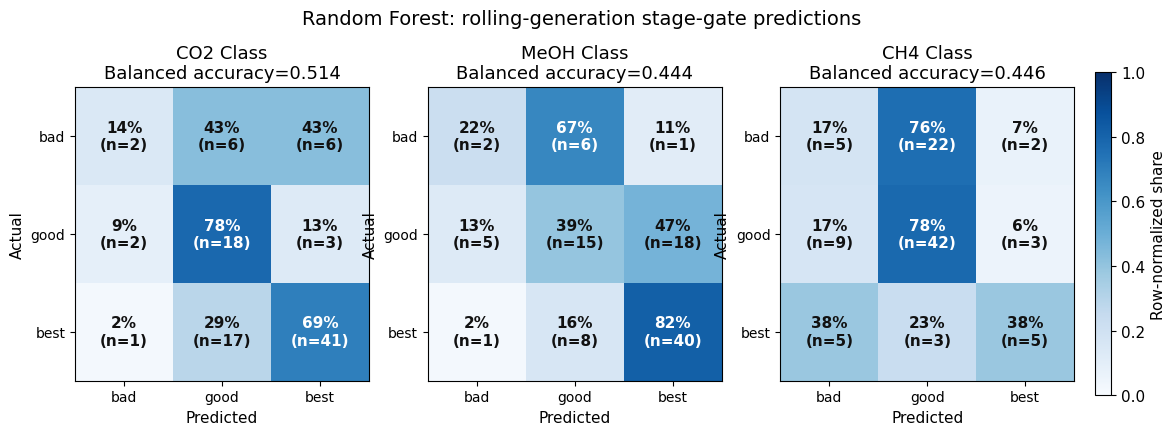

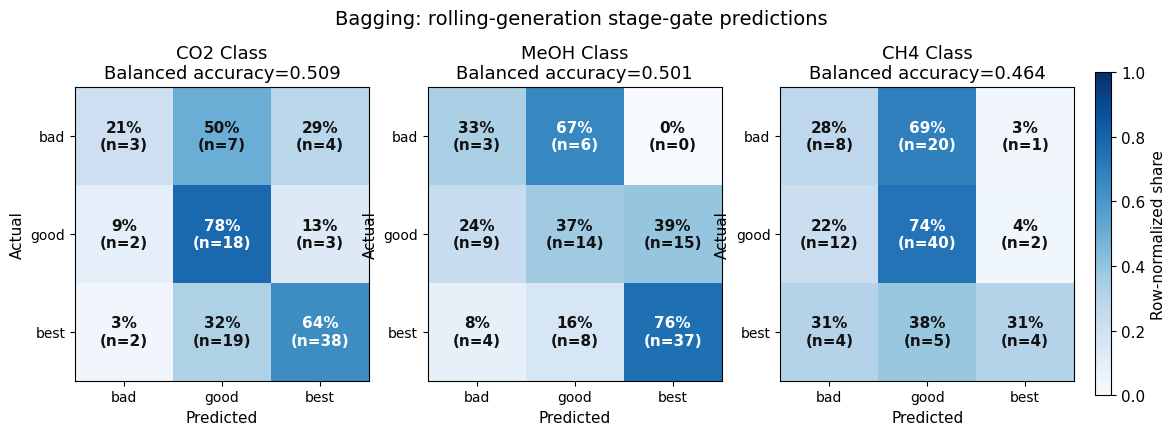

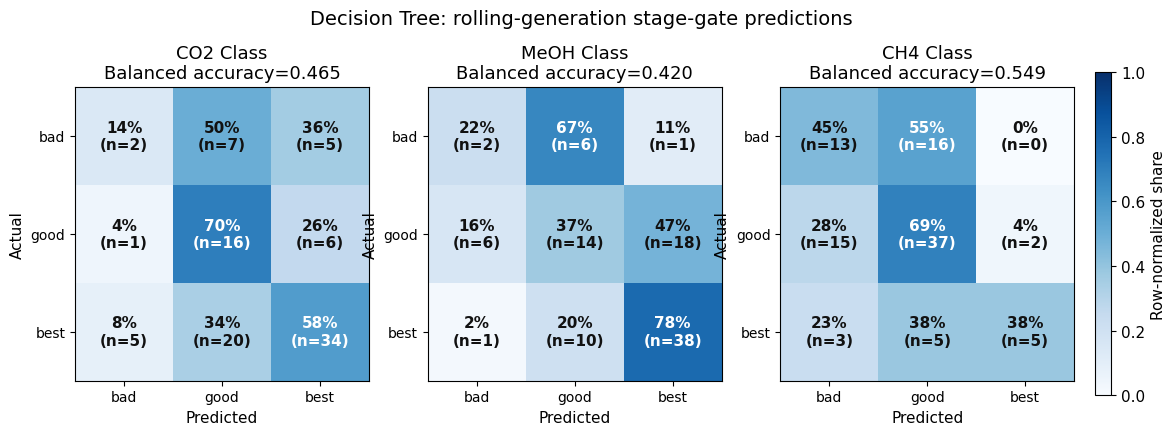

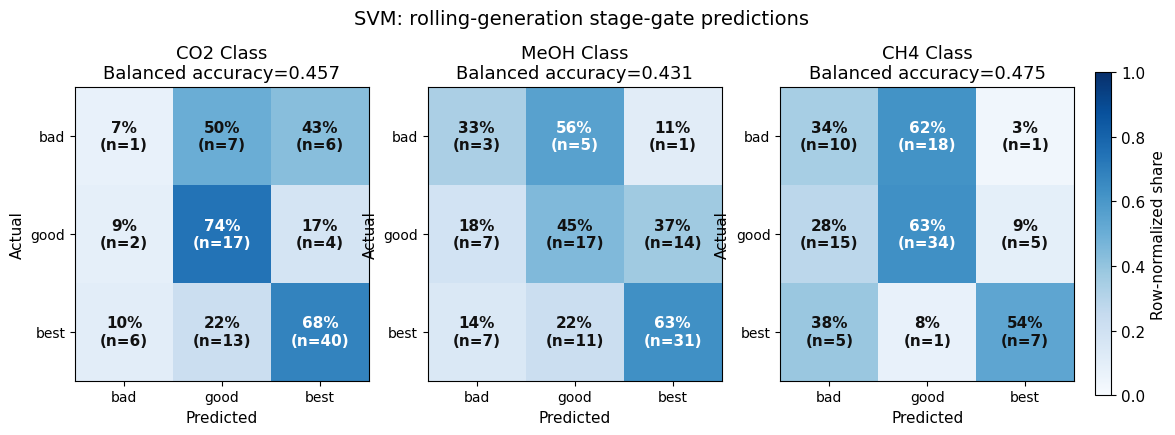

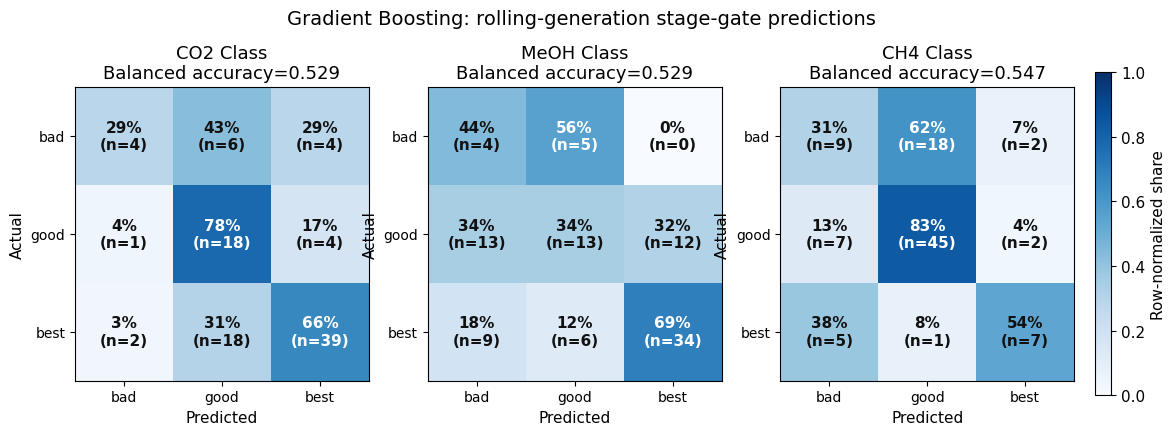

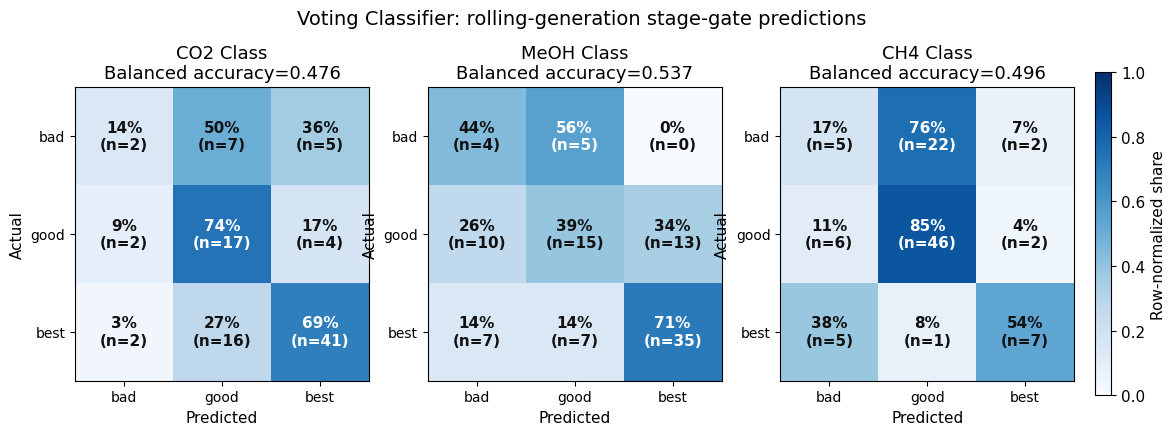

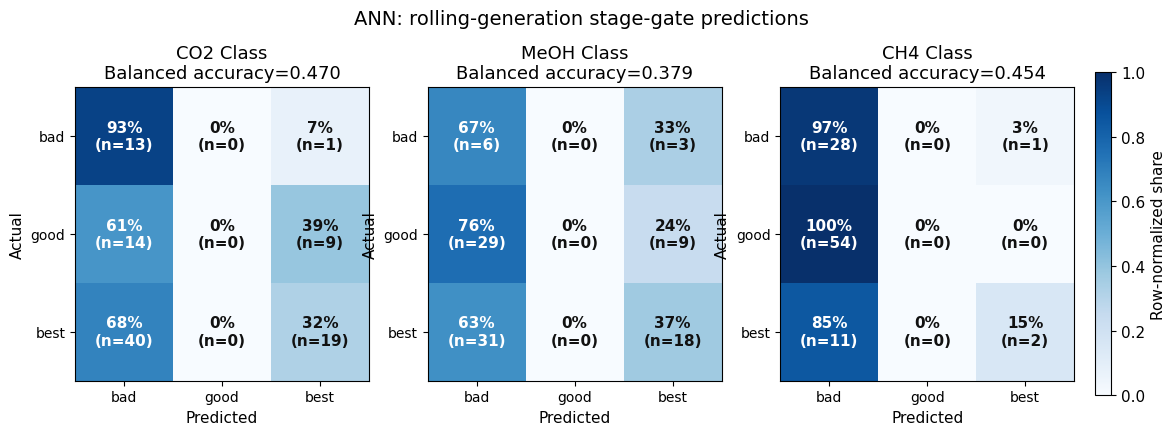

In [ ]:
for model_name in requested_models():
    fig,axes=plt.subplots(1,3,figsize=(13.5,4.2))
    for ax,(target_name,_) in zip(axes,TARGET_SPECS.items()):
        subset=classification_predictions[(classification_predictions.model==model_name)&(classification_predictions.target==target_name)]
        counts=confusion_matrix(subset.actual,subset.predicted,labels=CLASS_ORDER)
        matrix=confusion_matrix(subset.actual,subset.predicted,labels=CLASS_ORDER,normalize='true')
        image=ax.imshow(matrix,vmin=0,vmax=1,cmap='Blues')
        for i in range(3):
            for j in range(3):
                ax.text(j,i,f'{matrix[i,j]:.0%}\n(n={counts[i,j]})',ha='center',va='center',fontsize=11,fontweight='bold',
                        fontfamily='DejaVu Sans',color='white' if matrix[i,j]>.55 else '#111111')
        mean_score=model_target_summary.query('model==@model_name and target==@target_name').balanced_accuracy.iloc[0]
        ax.set(title=f'{target_name}\nBalanced accuracy={mean_score:.3f}',xticks=range(3),yticks=range(3),xticklabels=CLASS_ORDER,yticklabels=CLASS_ORDER,xlabel='Predicted',ylabel='Actual')
        ax.tick_params(axis='both',labelsize=10)
    fig.suptitle(f'{model_name}: rolling-generation stage-gate predictions',fontsize=14,y=1.03)
    fig.colorbar(image,ax=axes.ravel().tolist(),label='Row-normalized share',fraction=.025,pad=.02)
    plt.show()


#### All requested models grouped together

This is the direct predictive-power comparison requested. Bars are mean balanced accuracy across rolling held-out generations; higher is better. The dashed line is the three-class chance reference, not a claim of statistical significance.


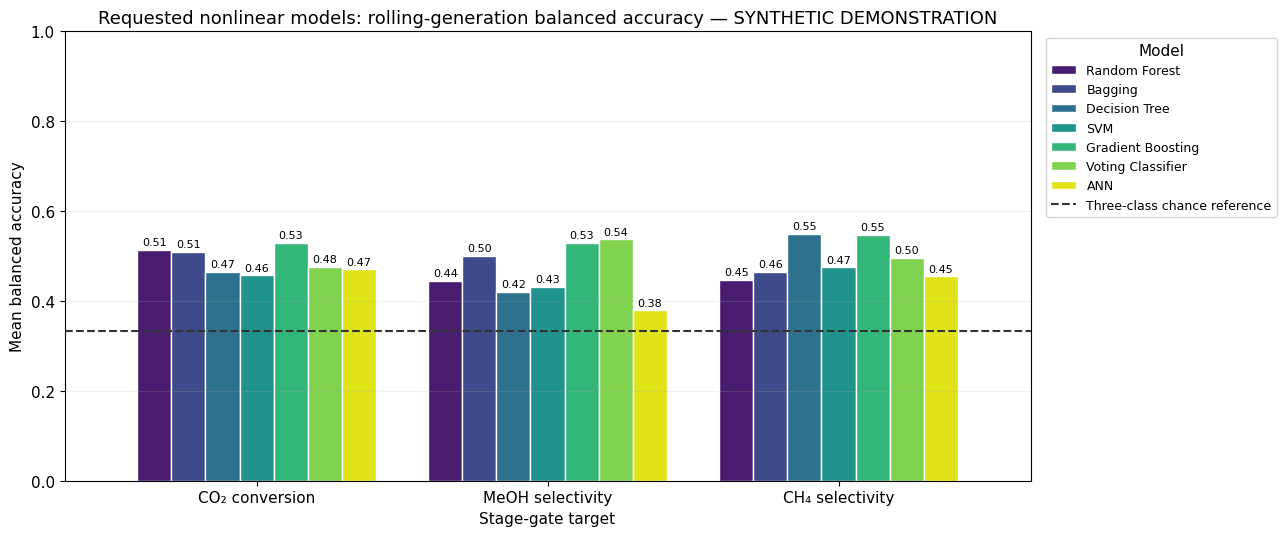

In [ ]:
from matplotlib.patches import Patch
comparison_wide=model_target_summary.pivot(index='target',columns='model',values='balanced_accuracy').reindex(TARGET_SPECS.keys())
model_order=['Random Forest','Bagging','Decision Tree','SVM','Gradient Boosting','Voting Classifier','ANN']
comparison_wide=comparison_wide[model_order]
model_colors=dict(zip(model_order,plt.cm.viridis(np.linspace(.08,.95,len(model_order)))))
ax=comparison_wide.plot(kind='bar',figsize=(13,5.5),width=.82,color=[model_colors[m] for m in model_order],edgecolor='white',legend=False)
ax.axhline(1/3,color='#333333',ls='--',label='Three-class chance reference')
ax.set(title=f'Requested nonlinear models: rolling-generation balanced accuracy — {DATA_MODE}',xlabel='Stage-gate target',ylabel='Mean balanced accuracy',ylim=(0,1))
handles=[Patch(facecolor=model_colors[m],edgecolor='white',label=m) for m in model_order]
handles.append(plt.Line2D([0],[0],color='#333333',ls='--',label='Three-class chance reference'))
ax.legend(handles=handles,title='Model',loc='upper left',bbox_to_anchor=(1.01,1),frameon=True,prop={'family':'DejaVu Sans','size':9})
ax.grid(axis='y',alpha=.2); ax.set_xticklabels(['CO₂ conversion','MeOH selectivity','CH₄ selectivity'],rotation=0)
for container in ax.containers:
    ax.bar_label(container,fmt='%.2f',padding=2,fontsize=8,fontfamily='DejaVu Sans')
plt.tight_layout(); plt.show()


### 6. Bootstrap model stability inside the historical training window

This resampling is used only inside Generations 1–4. Model choice is based on the earlier rolling folds (held-out Generations 2–4), and Generation 5 remains the external decision test. Each bootstrap resamples complete experimental rows, recalculates stage-gate thresholds, refits preprocessing and the selected model, and measures both balanced accuracy and how often each Generation 5 candidate appears in the predicted top five.


In [ ]:
N_BOOTSTRAPS=50
BOOTSTRAP_TOP_K=5
rng=np.random.default_rng(RANDOM_SEED)
historical_scores=classification_scores[classification_scores.generation<5]
selected_by_target=(historical_scores.groupby(['target','model'],as_index=False).balanced_accuracy.mean()
                    .sort_values('balanced_accuracy',ascending=False).groupby('target',as_index=False).first())

bootstrap_metrics=[]; selection_records=[]
bootstrap_train=model_df[model_df.generation_num<5].reset_index(drop=True)
prospective_test=model_df[model_df.generation_num==5].reset_index(drop=True)

# Define the numerical label for 'best' once.
best_numerical_label_value = CLASS_ORDER.index('best')

for target_name,(target_column,reverse) in TARGET_SPECS.items():
    model_name=selected_by_target.loc[selected_by_target.target==target_name,'model'].iloc[0]
    reference_low,reference_high=bootstrap_train[target_column].quantile([.33,.66])

    # Initialize OrdinalEncoder for consistent numerical mapping of classes
    le = OrdinalEncoder(categories=[CLASS_ORDER])

    y_test_string=stage_labels(prospective_test[target_column],reference_low,reference_high,reverse)

    for bootstrap_id in range(N_BOOTSTRAPS):
        sampled_positions=rng.integers(0,len(bootstrap_train),len(bootstrap_train))
        sampled=bootstrap_train.iloc[sampled_positions].copy()
        low,high=sampled[target_column].quantile([.33,.66])
        y_sample_string=stage_labels(sampled[target_column],low,high,reverse)

        # Fit and transform y_sample with the OrdinalEncoder
        y_sample_encoded = le.fit_transform(y_sample_string.reshape(-1, 1)).ravel()

        local_preprocessor=clone(pre)
        X_sample=local_preprocessor.fit_transform(sampled); X_test=local_preprocessor.transform(prospective_test)

        model=requested_models()[model_name]
        model.fit(X_sample,y_sample_encoded) # Fit with numerical labels
        predicted_encoded=model.predict(X_test)

        # Convert predicted numerical labels back to strings for balanced_accuracy_score
        predicted_string = le.inverse_transform(predicted_encoded.reshape(-1, 1)).ravel()

        bootstrap_metrics.append([target_name,model_name,bootstrap_id,balanced_accuracy_score(y_test_string,predicted_string)])

        # Get the class index for 'best' from the model's classes, if it exists
        if best_numerical_label_value in model.classes_:
            class_index = list(model.classes_).index(best_numerical_label_value)
            best_probability=model.predict_proba(X_test)[:,class_index]
        else:
            # If 'best' class is not in model.classes_ (meaning it wasn't in the training sample),
            # assume probability of 'best' is zero for all instances.
            best_probability = np.zeros(len(X_test))

        selected=np.argsort(best_probability)[::-1][:BOOTSTRAP_TOP_K]
        selection_records.extend([[target_name,model_name,bootstrap_id,prospective_test.loc[i,'Experiment ID']] for i in selected])

bootstrap_metrics=pd.DataFrame(bootstrap_metrics,columns=['target','model','bootstrap_id','balanced_accuracy'])
bootstrap_selection=pd.DataFrame(selection_records,columns=['target','model','bootstrap_id','Experiment ID'])
bootstrap_stability=(bootstrap_selection.groupby(['target','model','Experiment ID']).size().div(N_BOOTSTRAPS)
                     .rename('top5_selection_stability').reset_index())
bootstrap_summary=(bootstrap_metrics.groupby(['target','model']).balanced_accuracy
                   .agg(median='median',p05=lambda s:s.quantile(.05),p95=lambda s:s.quantile(.95)).reset_index())
display(bootstrap_summary.round(3))

,target,model,median,p05,p95
0,CH4 Class,Decision Tree,0.547,0.375,0.659
1,CO2 Class,Gradient Boosting,0.556,0.356,0.723
2,MeOH Class,Gradient Boosting,0.477,0.337,0.575


#### Candidate-selection stability

The graphs show how often each Generation 5 candidate was placed in the predicted top five across 50 bootstrap refits. High stability means the recommendation is less sensitive to which historical rows happened to be sampled.


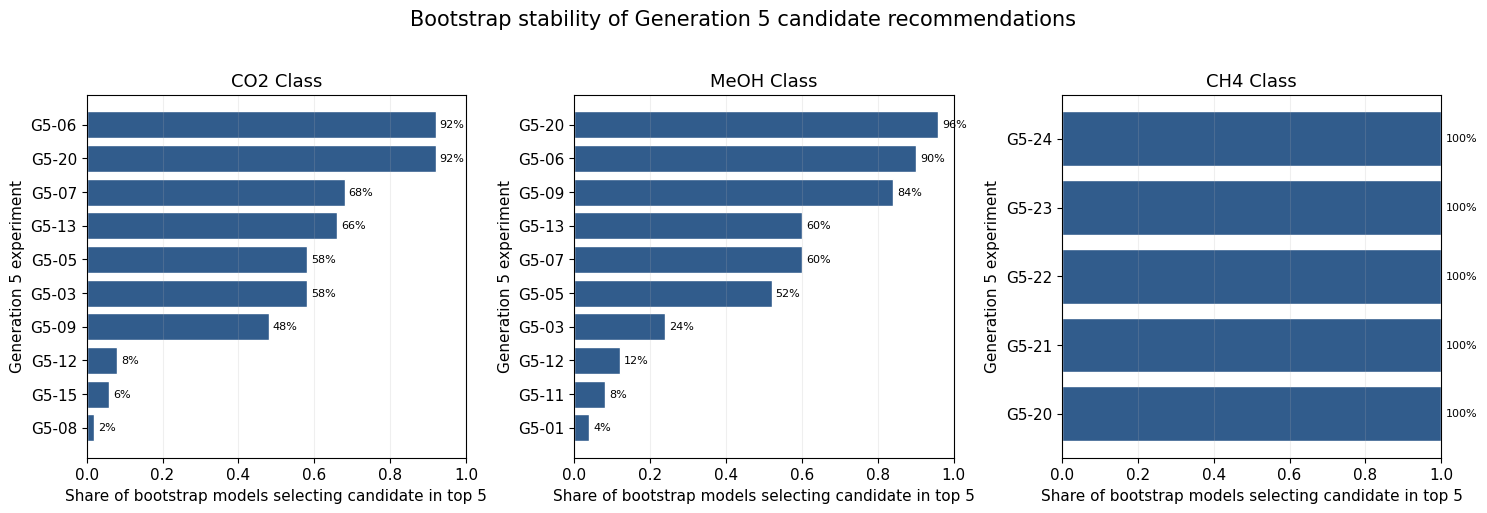

In [ ]:
fig,axes=plt.subplots(1,3,figsize=(15,5))
for ax,target_name in zip(axes,TARGET_SPECS):
    view=(bootstrap_stability[bootstrap_stability.target==target_name]
          .nlargest(10,'top5_selection_stability').sort_values('top5_selection_stability'))
    bars=ax.barh(view['Experiment ID'],view.top5_selection_stability,color='#315C8C',edgecolor='white')
    ax.set(title=target_name,xlabel='Share of bootstrap models selecting candidate in top 5',ylabel='Generation 5 experiment',xlim=(0,1))
    ax.bar_label(bars,labels=[f'{v:.0%}' for v in view.top5_selection_stability],padding=3,fontsize=8)
    ax.grid(axis='x',alpha=.2)
fig.suptitle('Bootstrap stability of Generation 5 candidate recommendations',fontsize=15,y=1.02)
fig.tight_layout(); plt.show()


### 8. Interpretable unsupervised learning: composition drivers and formulation archetypes

This section uses only two unsupervised models with directly readable outputs. **Principal component analysis (PCA)** shows which composition variables explain the main directions of variation and how experimental generations moved through that space. **Non-negative matrix factorization (NMF)** represents every catalyst as a mixture of three non-negative metal archetypes, so each latent pattern can be described by its dominant metals.

These are descriptive models of the tested formulation space. They do not establish causal chemistry or prove that an archetype will perform well in a future experiment.


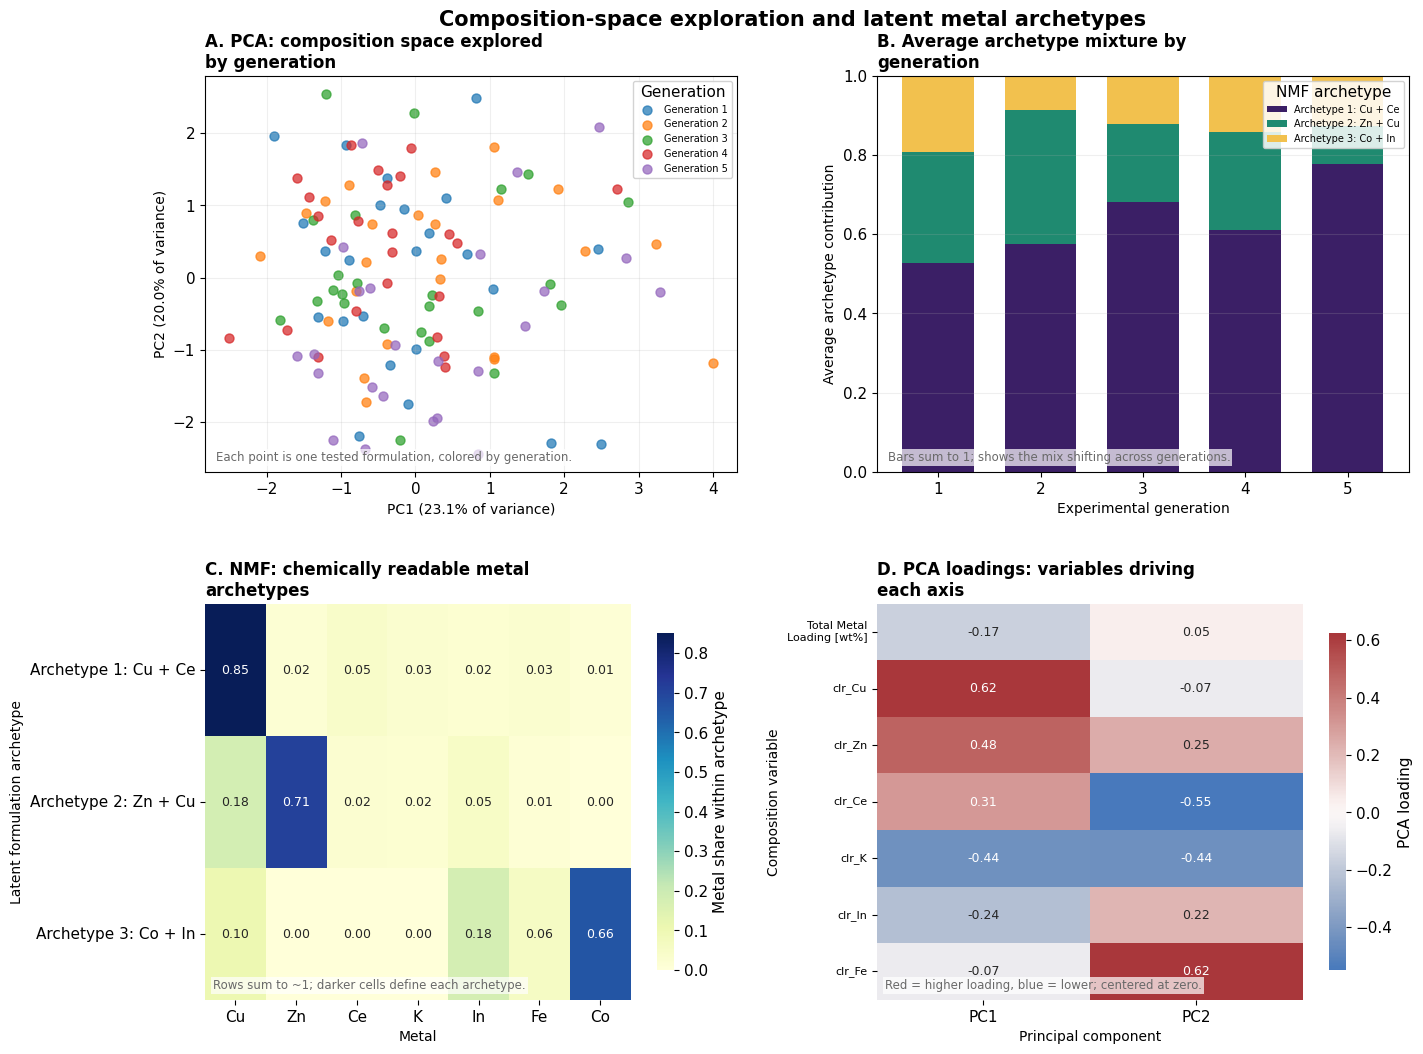

In [ ]:
import textwrap

TITLE_FS, LABEL_FS, CAPTION_FS = 12, 10, 8.5

def wrap_title(text, width=34):
    return "\n".join(textwrap.wrap(text, width))

def caption(ax, text):
    ax.text(0.02, 0.02, text, transform=ax.transAxes, ha='left', va='bottom',
            fontsize=CAPTION_FS, color='dimgray',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5))

fig = plt.figure(figsize=(14, 11))

left_x, right_x = 0.08, 0.56
col_w            = 0.38
top_y, bottom_y  = 0.56, 0.08
row_h            = 0.36

ax_scatter   = fig.add_axes([left_x,  top_y,    col_w, row_h])  # top-left    -> A
ax_bar       = fig.add_axes([right_x, top_y,    col_w, row_h])  # top-right   -> B (was D)
ax_nmf_heat  = fig.add_axes([left_x,  bottom_y, col_w, row_h])  # bottom-left -> C
ax_load      = fig.add_axes([right_x, bottom_y, col_w, row_h])  # bottom-right-> D (was B)

# A — PCA scatter
for generation, group in model_df.groupby('generation_num'):
    ax_scatter.scatter(group.PC1, group.PC2, s=42, alpha=.72, label=f'Generation {int(generation)}')
ax_scatter.set_title(wrap_title('A. PCA: composition space explored by generation'), fontsize=TITLE_FS, loc='left', weight='bold')
ax_scatter.set_xlabel(f'PC1 ({pca_variance[0]:.1%} of variance)', fontsize=LABEL_FS)
ax_scatter.set_ylabel(f'PC2 ({pca_variance[1]:.1%} of variance)', fontsize=LABEL_FS)
ax_scatter.legend(title='Generation', fontsize=7, loc='upper right', framealpha=0.85)
ax_scatter.grid(alpha=.2)
caption(ax_scatter, 'Each point is one tested formulation, colored by generation.')

# B — archetype mixture by generation (moved here from D)
archetype_colors = ['#3b1f66', '#1f8a70', '#f2c14e']
generation_archetypes.plot(kind='bar', stacked=True, ax=ax_bar, color=archetype_colors, width=0.7, legend=False)
ax_bar.set_title(wrap_title('B. Average archetype mixture by generation'), fontsize=TITLE_FS, loc='left', weight='bold')
ax_bar.set_xlabel('Experimental generation', fontsize=LABEL_FS)
ax_bar.set_ylabel('Average archetype contribution', fontsize=LABEL_FS)
ax_bar.set_ylim(0, 1)
ax_bar.tick_params(axis='x', rotation=0)
ax_bar.grid(axis='y', alpha=.2)
ax_bar.legend(title='NMF archetype', fontsize=7, loc='upper right', framealpha=0.85)
caption(ax_bar, 'Bars sum to 1; shows the mix shifting across generations.')

# C — NMF archetypes
archetype_labels = [f'Archetype {i+1}: {n}' for i, n in enumerate(archetype_names)]
sns.heatmap(pd.DataFrame(H_share, index=archetype_labels, columns=METALS), annot=True, fmt='.2f',
            cmap='YlGnBu', ax=ax_nmf_heat, cbar_kws={'label': 'Metal share within archetype', 'shrink': 0.85},
            annot_kws={'fontsize': 9})
ax_nmf_heat.set_title(wrap_title('C. NMF: chemically readable metal archetypes'), fontsize=TITLE_FS, loc='left', weight='bold')
ax_nmf_heat.set_xlabel('Metal', fontsize=LABEL_FS)
ax_nmf_heat.set_ylabel('Latent formulation archetype', fontsize=LABEL_FS)
caption(ax_nmf_heat, 'Rows sum to ~1; darker cells define each archetype.')

# D — PCA loadings (moved here from B)
pca_loadings_display = pca_loadings.rename(index={'Total Metal Loading [wt%]': 'Total Metal\nLoading [wt%]'})
sns.heatmap(pca_loadings_display, annot=True, fmt='.2f', center=0, cmap='vlag', ax=ax_load,
            cbar_kws={'label': 'PCA loading', 'shrink': 0.85}, annot_kws={'fontsize': 9})
ax_load.set_yticklabels(ax_load.get_yticklabels(), rotation=0, fontsize=LABEL_FS - 2)
ax_load.set_title(wrap_title('D. PCA loadings: variables driving each axis'), fontsize=TITLE_FS, loc='left', weight='bold')
ax_load.set_xlabel('Principal component', fontsize=LABEL_FS)
ax_load.set_ylabel('Composition variable', fontsize=LABEL_FS)
caption(ax_load, 'Red = higher loading, blue = lower; centered at zero.')

fig.suptitle('Composition-space exploration and latent metal archetypes', fontsize=15, weight='bold', y=0.98)
plt.show()

### 9. Screening TEA, prospective LCA, and financial bottom line

These low/base/high scenarios make the strategy link explicit:

**R&D choices → candidate productivity/uncertainty → NPD stage-gate throughput → process yield/energy → unit economics and CO₂e → portfolio value.**

The catalyst dataset alone cannot determine production cost, contribution margin, NPV, or product LCA. Assumptions below are placeholders and must be replaced by process engineering, procurement, finance, and LCA owners.


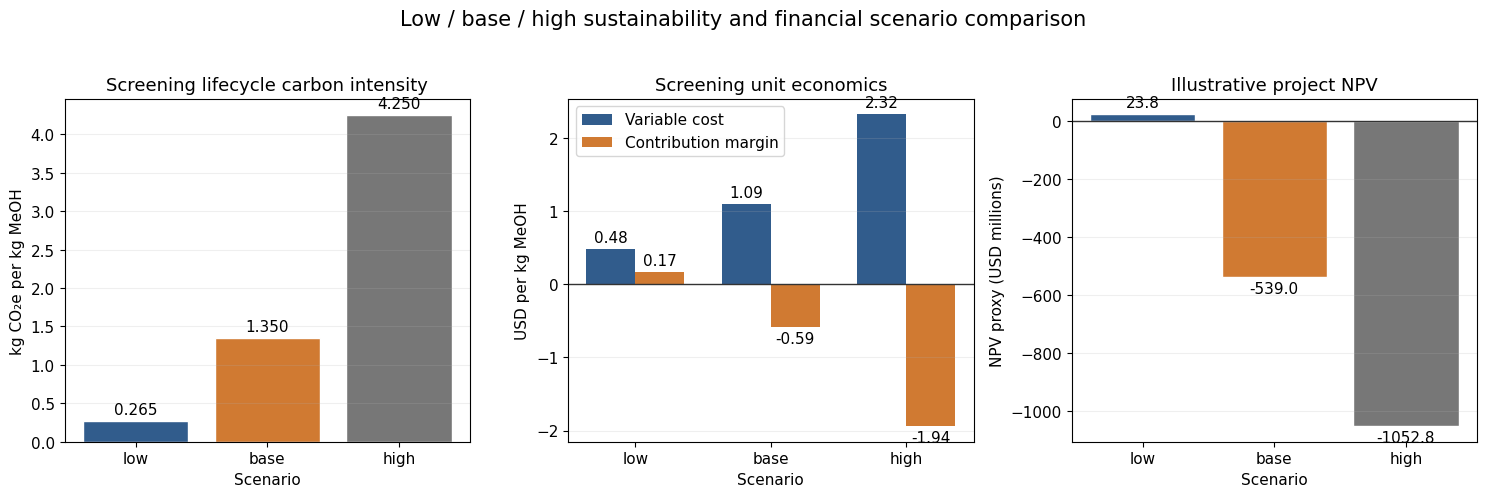

In [ ]:
scenarios=pd.DataFrame({
 'scenario':['low','base','high'],
 'H2_kg_per_kg_MeOH':[.19,.20,.23], 'H2_cost_per_kg':[2.0,4.0,7.0], 'H2_kgCO2e_per_kg':[1.0,4.0,11.0],
 'electricity_kWh_per_kg':[.5,1.0,1.8], 'electricity_cost_per_kWh':[.04,.08,.15], 'electricity_kgCO2e_per_kWh':[.03,.35,.65],
 'CO2_cost_per_kg':[.03,.08,.15], 'separation_cost_per_kg':[.05,.12,.25], 'other_process_kgCO2e':[.05,.15,.35],
 'catalyst_cost_per_kg_MeOH':[.002,.01,.04], 'catalyst_kgCO2e_per_kg_MeOH':[.01,.05,.20],
 'methanol_price_per_kg':[.65,.50,.38], 'annual_saleable_kg':[100e6,80e6,60e6], 'capex_USD':[120e6,180e6,260e6],
 'discount_rate':[.08,.10,.12], 'project_years':[15,15,15]})
scenarios['screening_CO2e_kg_per_kg_MeOH']=scenarios.H2_kg_per_kg_MeOH*scenarios.H2_kgCO2e_per_kg+scenarios.electricity_kWh_per_kg*scenarios.electricity_kgCO2e_per_kWh+scenarios.other_process_kgCO2e+scenarios.catalyst_kgCO2e_per_kg_MeOH
scenarios['variable_cost_per_kg']=scenarios.H2_kg_per_kg_MeOH*scenarios.H2_cost_per_kg+scenarios.electricity_kWh_per_kg*scenarios.electricity_cost_per_kWh+scenarios.CO2_cost_per_kg+scenarios.separation_cost_per_kg+scenarios.catalyst_cost_per_kg_MeOH
scenarios['contribution_margin_per_kg']=scenarios.methanol_price_per_kg-scenarios.variable_cost_per_kg
scenarios['annual_FCF_proxy']=scenarios.contribution_margin_per_kg*scenarios.annual_saleable_kg
scenarios['NPV_proxy_USD']=[-r.capex_USD+sum(r.annual_FCF_proxy/(1+r.discount_rate)**t for t in range(1,int(r.project_years)+1)) for _,r in scenarios.iterrows()]
scenario_colors=['#315C8C','#D07A32','#777777']
fig,axes=plt.subplots(1,3,figsize=(15,4.8))

bars=axes[0].bar(scenarios.scenario,scenarios.screening_CO2e_kg_per_kg_MeOH,color=scenario_colors,edgecolor='white')
axes[0].set_title('Screening lifecycle carbon intensity')
axes[0].set_xlabel('Scenario'); axes[0].set_ylabel('kg CO₂e per kg MeOH')
axes[0].bar_label(bars,fmt='%.3f',padding=3)

x=np.arange(len(scenarios)); width=.36
cost_bars=axes[1].bar(x-width/2,scenarios.variable_cost_per_kg,width,label='Variable cost',color='#315C8C')
margin_bars=axes[1].bar(x+width/2,scenarios.contribution_margin_per_kg,width,label='Contribution margin',color='#D07A32')
axes[1].axhline(0,color='#333333',lw=1)
axes[1].set_title('Screening unit economics'); axes[1].set_xlabel('Scenario'); axes[1].set_ylabel('USD per kg MeOH')
axes[1].set_xticks(x,scenarios.scenario); axes[1].legend()
axes[1].bar_label(cost_bars,fmt='%.2f',padding=3); axes[1].bar_label(margin_bars,fmt='%.2f',padding=3)

npv_millions=scenarios.NPV_proxy_USD/1e6
npv_bars=axes[2].bar(scenarios.scenario,npv_millions,color=scenario_colors,edgecolor='white')
axes[2].axhline(0,color='#333333',lw=1)
axes[2].set_title('Illustrative project NPV'); axes[2].set_xlabel('Scenario'); axes[2].set_ylabel('NPV proxy (USD millions)')
axes[2].bar_label(npv_bars,fmt='%.1f',padding=3)

for ax in axes: ax.grid(axis='y',alpha=.2)
fig.suptitle('Low / base / high sustainability and financial scenario comparison',fontsize=15,y=1.03)
fig.tight_layout(); plt.show()


## Takeaways

The statements below are generated from the notebook's calculated outputs. They do not add external claims from the attached climate-mitigation document.


In [ ]:
# @title
best_by_target=(model_target_summary.sort_values('balanced_accuracy',ascending=False)
                .groupby('target',as_index=False).first())
overall_models=(model_target_summary.groupby('model').balanced_accuracy.mean().sort_values(ascending=False))
g1=kpi_summary[kpi_summary.Generation=='1'].iloc[0]
g5=kpi_summary[kpi_summary.Generation=='5'].iloc[0]
priced_only=kpi_summary[~kpi_summary.Generation.astype(str).str.contains('NoCost')]
best_cost_row=priced_only.loc[priced_only.cost_efficiency_best.idxmax()]
sign_reversals=confounding[confounding.sign_reversal_candidate]
significant_reversals=sign_reversals[sign_reversals.adjusted_p_value<.05]
pca_variance_total=pca_variance.sum()
pc1_drivers=', '.join(pca_loadings.PC1.abs().nlargest(3).index)
pc2_drivers=', '.join(pca_loadings.PC2.abs().nlargest(3).index)
archetype_summary='; '.join([f'Archetype {i+1}: {name}' for i,name in enumerate(archetype_names)])
positive_scenarios=scenarios[scenarios.contribution_margin_per_kg>0].scenario.tolist()
no_cost_rows=int(df.is_no_cost_cohort.sum())
no_cost_cost_coverage=int(df.loc[df.is_no_cost_cohort,'Cost [$/kg]'].notna().sum())
yield_change=(g5.yield_proxy_median/g1.yield_proxy_median-1)*100 if g1.yield_proxy_median else np.nan

model_lines='\n'.join([f"- **{row.target}:** {row.model} produced the highest mean rolling balanced accuracy ({row.balanced_accuracy:.3f})." for _,row in best_by_target.iterrows()])
bootstrap_lines='\n'.join([f"- **{row.target} bootstrap:** {row.model} median balanced accuracy {row['median']:.3f} (5th–95th percentile: {row.p05:.3f}–{row.p95:.3f})." for _,row in bootstrap_summary.iterrows()])
scenario_text=', '.join(positive_scenarios) if positive_scenarios else 'none'
reversal_text=(f"{len(sign_reversals)} sign reversals were flagged, but {len(significant_reversals)} remained significant at p < 0.05 after adjustment."
               if len(sign_reversals) else 'No marginal-to-adjusted sign reversals were flagged.')
if no_cost_rows:
    no_cost_text=f'''- The loaded dataset contains **{no_cost_rows} `2_NoCost` rows**, with catalyst-cost coverage for **{no_cost_cost_coverage}** of them.
- **Primary analysis:** keep the chronological and commercially comparable cohort restricted to **Generations 1–5** for rolling prediction, generation comparisons, cost efficiency, and R&D-acceleration claims.
- **Optional chemistry-only sensitivity analysis:** use `2_NoCost` separately only after confirming protocol, measurement quality, replicates, and chronology. Never use it in cost-efficiency, TEA, or financial ranking without authoritative costs.'''
else:
    no_cost_text='''- The supplied workbook already contains only **Generations 1–5**, so the reported performance and cost comparisons use one consistent population.
- If the separate `2_NoCost` records are reviewed later, keep them outside the executive scorecard because they do not contain the cost information required for a fair business comparison.'''
evidence_mode=("The supplied workbook was loaded and hashed; the numerical findings below are observed within that file."
               if DATA_MODE=='OBSERVED' else "The source workbook was not found; numerical findings are synthetic workflow demonstrations.")

takeaway_text=f'''
### What the calculated results drive

#### 1. Confounding changes how support and metal effects should be interpreted

- Generations 2–5 use only ZrO₂ in the analyzed cohort, while Generation 1 contains several supports. Support is therefore entangled with experimental generation and campaign policy.
- {reversal_text} These are diagnostics of instability, not causal metal or support effects.
- **Decision implication:** use the fitted associations for prediction only. A support claim requires within-generation support crossover experiments and replicates.

#### 2. What the experimental campaign achieved

- A typical Generation 5 experiment converted a much larger share of the incoming CO₂ into methanol than a typical Generation 1 experiment: the combined yield indicator increased from **{g1.yield_proxy_median:.4f}** to **{g5.yield_proxy_median:.4f}**.
- Results did not improve in a straight line. The best individual productivity changed from generation to generation, which means one strong catalyst should not be mistaken for a repeatable platform.
- Generation **{best_cost_row.Generation}** produced the strongest measured combination of catalyst productivity and catalyst cost in this dataset.
- **Business implication:** the ML-guided campaign appears to have moved testing toward more promising formulations. Leadership should advance a small Generation {best_cost_row.Generation} shortlist into repeat testing, stability testing, and process validation—not directly into commercialization.

#### 3. What P1 and P2 imply for R&D strategy

- **P1 - support selection risk:** later generations concentrate entirely on ZrO₂. This may be an effective search decision, but it also creates premature lock-in risk and makes it impossible to separate the value of ZrO₂ from the value of later-generation formulations.
- **Business implication:** before standardizing ZrO₂, run a small controlled support comparison using otherwise similar formulations. This protects the company from committing to the wrong support, supplier, or manufacturing route.
- **P2 - prediction is target-specific:** no algorithm is best for every outcome. The notebook results are:

{model_lines}

- The strongest average model was **{overall_models.index[0]} ({overall_models.iloc[0]:.3f})**. CH₄ prediction remains materially weaker than CO₂ and methanol prediction.
- **Business implication:** use the models to prioritize laboratory work, not to automate go/no-go decisions. Keep separate models by target, and invest additional experiments in methane behavior because this is the least reliable risk screen.

#### 4. How stable the recommendations are

{bootstrap_lines}

- **Business implication:** prioritize candidates that remain in the top five across most bootstrap refits. Candidates selected only occasionally should be treated as exploratory rather than committed development bets.

#### 5. Interpretable unsupervised models describe how the search space changed

- The first two PCA axes summarize **{pca_variance_total:.1%}** of observed composition variation. The strongest PC1 drivers are **{pc1_drivers}**; the strongest PC2 drivers are **{pc2_drivers}**.
- NMF resolves three readable formulation patterns: **{archetype_summary}**. Its relative reconstruction error is **{nmf_relative_error:.3f}**, which reports how much composition detail is lost by the three-archetype simplification.
- **Decision implication:** use the PCA map to see whether later generations revisit or expand earlier formulation space, and use NMF to communicate which metal combinations dominate the tested portfolio. These are descriptive search-management tools, not validated performance families or causal mechanisms.

#### 6. What the business scenarios mean

- In the favorable case, the hypothetical product earns approximately **${scenarios.loc[scenarios.scenario=='low','contribution_margin_per_kg'].iloc[0]:.2f} per kg of methanol before fixed corporate costs**, with an illustrative NPV of **${scenarios.loc[scenarios.scenario=='low','NPV_proxy_USD'].iloc[0]/1e6:.1f} million**.
- In the base case, it loses approximately **${abs(scenarios.loc[scenarios.scenario=='base','contribution_margin_per_kg'].iloc[0]):.2f} per kg**; in the high-cost case, it loses approximately **${abs(scenarios.loc[scenarios.scenario=='high','contribution_margin_per_kg'].iloc[0]):.2f} per kg**.
- The climate result is equally sensitive: the screening footprint ranges from **{scenarios.screening_CO2e_kg_per_kg_MeOH.min():.3f}** to **{scenarios.screening_CO2e_kg_per_kg_MeOH.max():.3f} kg CO₂e/kg methanol**, depending mainly on hydrogen and energy assumptions.
- **Business implication:** the catalyst is only one part of the value proposition. The project becomes investable only if the company can secure sufficiently low-cost, low-carbon hydrogen and electricity and confirm realistic separation, catalyst-life, and plant-cost assumptions.

'''
display(Markdown(takeaway_text))



### What the calculated results drive

#### 1. Confounding changes how support and metal effects should be interpreted

- Generations 2–5 use only ZrO₂ in the analyzed cohort, while Generation 1 contains several supports. Support is therefore entangled with experimental generation and campaign policy.
- 2 sign reversals were flagged, but 0 remained significant at p < 0.05 after adjustment. These are diagnostics of instability, not causal metal or support effects.
- **Decision implication:** use the fitted associations for prediction only. A support claim requires within-generation support crossover experiments and replicates.

#### 2. What the experimental campaign achieved

- A typical Generation 5 experiment converted a much larger share of the incoming CO₂ into methanol than a typical Generation 1 experiment: the combined yield indicator increased from **0.0122** to **0.0327**.
- Results did not improve in a straight line. The best individual productivity changed from generation to generation, which means one strong catalyst should not be mistaken for a repeatable platform.
- Generation **4** produced the strongest measured combination of catalyst productivity and catalyst cost in this dataset.
- **Business implication:** the ML-guided campaign appears to have moved testing toward more promising formulations. Leadership should advance a small Generation 4 shortlist into repeat testing, stability testing, and process validation—not directly into commercialization.

#### 3. What P1 and P2 imply for R&D strategy

- **P1 - support selection risk:** later generations concentrate entirely on ZrO₂. This may be an effective search decision, but it also creates premature lock-in risk and makes it impossible to separate the value of ZrO₂ from the value of later-generation formulations.
- **Business implication:** before standardizing ZrO₂, run a small controlled support comparison using otherwise similar formulations. This protects the company from committing to the wrong support, supplier, or manufacturing route.
- **P2 - prediction is target-specific:** no algorithm is best for every outcome. The notebook results are:

- **CH4 Class:** Decision Tree produced the highest mean rolling balanced accuracy (0.549).
- **CO2 Class:** Gradient Boosting produced the highest mean rolling balanced accuracy (0.529).
- **MeOH Class:** Voting Classifier produced the highest mean rolling balanced accuracy (0.537).

- The strongest average model was **Gradient Boosting (0.535)**. CH₄ prediction remains materially weaker than CO₂ and methanol prediction.
- **Business implication:** use the models to prioritize laboratory work, not to automate go/no-go decisions. Keep separate models by target, and invest additional experiments in methane behavior because this is the least reliable risk screen.

#### 4. How stable the recommendations are

- **CH4 Class bootstrap:** Decision Tree median balanced accuracy 0.547 (5th–95th percentile: 0.375–0.659).
- **CO2 Class bootstrap:** Gradient Boosting median balanced accuracy 0.556 (5th–95th percentile: 0.356–0.723).
- **MeOH Class bootstrap:** Gradient Boosting median balanced accuracy 0.477 (5th–95th percentile: 0.337–0.575).

- **Business implication:** prioritize candidates that remain in the top five across most bootstrap refits. Candidates selected only occasionally should be treated as exploratory rather than committed development bets.

#### 5. Interpretable unsupervised models describe how the search space changed

- The first two PCA axes summarize **43.1%** of observed composition variation. The strongest PC1 drivers are **clr_Cu, clr_Zn, clr_K**; the strongest PC2 drivers are **clr_Fe, clr_Ce, clr_K**.
- NMF resolves three readable formulation patterns: **Archetype 1: Cu + Ce; Archetype 2: Zn + Cu; Archetype 3: Co + In**. Its relative reconstruction error is **0.183**, which reports how much composition detail is lost by the three-archetype simplification.
- **Decision implication:** use the PCA map to see whether later generations revisit or expand earlier formulation space, and use NMF to communicate which metal combinations dominate the tested portfolio. These are descriptive search-management tools, not validated performance families or causal mechanisms.

#### 6. What the business scenarios mean 

- In the favorable case, the hypothetical product earns approximately **$0.17 per kg of methanol before fixed corporate costs**, with an illustrative NPV of **$23.8 million**.
- In the base case, it loses approximately **$0.59 per kg**; in the high-cost case, it loses approximately **$1.94 per kg**.
- The climate result is equally sensitive: the screening footprint ranges from **0.265** to **4.250 kg CO₂e/kg methanol**, depending mainly on hydrogen and energy assumptions.
- **Business implication:** the catalyst is only one part of the value proposition. The project becomes investable only if the company can secure sufficiently low-cost, low-carbon hydrogen and electricity and confirm realistic separation, catalyst-life, and plant-cost assumptions.

